In [1]:

!pip install -q kaggle


In [2]:

import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_389ca91625735853cfad3720e38b6417"

print("Kaggle API Token ayarlandı")


Kaggle API Token ayarlandı


In [3]:

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("kaggle.json doğru klasöre taşındı")


kaggle.json doğru klasöre taşındı


In [4]:

!pip install -q kaggle
!kaggle datasets download -d berkaykocaoglu/tr-sign-language -p /content --unzip


Dataset URL: https://www.kaggle.com/datasets/berkaykocaoglu/tr-sign-language
License(s): unknown
 92% 0.98G/1.06G [00:00<00:00, 1.65GB/s]
100% 1.06G/1.06G [00:00<00:00, 1.68GB/s]


In [5]:

import os

DATASET_ROOT = None
for root, dirs, files in os.walk("/content"):
    if "train" in dirs and "test" in dirs:
        DATASET_ROOT = root
        print("DATASET ROOT BULUNDU:", DATASET_ROOT)
        break

assert DATASET_ROOT is not None, "Dataset root bulunamadı!"


DATASET ROOT BULUNDU: /content/tr_signLanguage_dataset


In [6]:

train_dir = os.path.join(DATASET_ROOT, "train")
test_dir  = os.path.join(DATASET_ROOT, "test")

print("Train exists:", os.path.isdir(train_dir))
print("Test exists :", os.path.isdir(test_dir))

class_names = sorted(os.listdir(train_dir))
print("Sınıf sayısı:", len(class_names))
print("İlk 10 sınıf:", class_names[:10])


Train exists: True
Test exists : True
Sınıf sayısı: 26
İlk 10 sınıf: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


In [7]:

import torch
from torchvision import datasets, transforms


In [8]:


IMG_SIZE = 128

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


In [9]:


full_train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=val_test_transform
)

print("Toplam train görüntü sayısı:", len(full_train_dataset))
print("Toplam test görüntü sayısı :", len(test_dataset))
print("Sınıf sayısı:", len(full_train_dataset.classes))


Toplam train görüntü sayısı: 119400
Toplam test görüntü sayısı : 47796
Sınıf sayısı: 26


In [10]:

from torch.utils.data import random_split

SEED = 42
torch.manual_seed(SEED)

train_ratio = 0.8
val_ratio   = 0.2

total_size = len(full_train_dataset)
train_size = int(train_ratio * total_size)
val_size   = total_size - train_size

print("Train size:", train_size)
print("Val size  :", val_size)


Train size: 95520
Val size  : 23880


In [11]:

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Train subset:", len(train_dataset))
print("Val subset  :", len(val_dataset))


Train subset: 95520
Val subset  : 23880


In [12]:

from torch.utils.data import DataLoader

def get_dataloaders(train_ds, val_ds, test_ds, batch_size):
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader


In [13]:

BATCH_SIZE = 64

train_loader, val_loader, test_loader = get_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset,
    batch_size=BATCH_SIZE
)


images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)


Batch image shape: torch.Size([64, 3, 128, 128])
Batch label shape: torch.Size([64])


In [14]:

import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


In [15]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan device:", device)


Kullanılan device: cuda


In [16]:

def build_efficientnet_b0(num_classes=26, dropout=0.5, freeze=True):
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)


    if freeze:
        for param in model.features.parameters():
            param.requires_grad = False


    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    return model.to(device)


In [17]:

model_eff = build_efficientnet_b0()

x, _ = next(iter(train_loader))
x = x.to(device)

with torch.no_grad():
    out = model_eff(x)

print("Model output shape:", out.shape)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 57.0MB/s]


Model output shape: torch.Size([64, 26])


In [18]:

criterion = nn.CrossEntropyLoss()
print("Loss function: CrossEntropyLoss")


Loss function: CrossEntropyLoss


In [19]:

import torch.optim as optim

def get_optimizer(model, lr, opt_name):
    if opt_name == "adam":
        return optim.Adam(model.classifier.parameters(), lr=lr)
    elif opt_name == "sgd":
        return optim.SGD(
            model.classifier.parameters(),
            lr=lr,
            momentum=0.9
        )
    else:
        raise ValueError("Bilinmeyen optimizer")


In [20]:

effnet_configs = [
    {"lr": 1e-3,  "batch": 64,  "opt": "adam"},
    {"lr": 5e-4,  "batch": 64,  "opt": "adam"},
    {"lr": 3e-4,  "batch": 128, "opt": "adam"},
    {"lr": 5e-4,  "batch": 64,  "opt": "sgd"},
]


In [21]:

effnet_tuning_results = []
print("Tuning altyapısı hazır")


Tuning altyapısı hazır


In [22]:

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


In [23]:

def validate_one_epoch(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


In [24]:

def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion
        )
        val_loss, val_acc = validate_one_epoch(
            model, val_loader, criterion
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
        )

    return history


In [25]:

TUNING_EPOCHS = 2
print("Tuning epochs:", TUNING_EPOCHS)


Tuning epochs: 2


In [26]:

effnet_tuning_results = []

for i, cfg in enumerate(effnet_configs, start=1):
    print(f"\n==================== EfficientNet-B0 Tuning {i}/{len(effnet_configs)} ====================")
    print("Config:", cfg)


    train_loader, val_loader, _ = get_dataloaders(
        train_dataset,
        val_dataset,
        test_dataset,
        batch_size=cfg["batch"]
    )


    model = build_efficientnet_b0(
        num_classes=26,
        dropout=0.5,
        freeze=True
    )


    optimizer = get_optimizer(
        model,
        lr=cfg["lr"],
        opt_name=cfg["opt"]
    )


    history = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=TUNING_EPOCHS
    )

    best_val_acc = max(history["val_acc"])
    effnet_tuning_results.append({
        "config": cfg,
        "best_val_acc": best_val_acc
    })

    print(f"--> Best Val Acc: {best_val_acc:.4f}")



==================== EfficientNet-B0 Tuning 1/4 ====================
Config: {'lr': 0.001, 'batch': 64, 'opt': 'adam'}
Epoch [1/2] | Train Loss: 1.2763 Acc: 0.6358 | Val Loss: 0.6494 Acc: 0.8277
Epoch [2/2] | Train Loss: 0.9731 Acc: 0.6982 | Val Loss: 0.5476 Acc: 0.8461
--> Best Val Acc: 0.8461

==================== EfficientNet-B0 Tuning 2/4 ====================
Config: {'lr': 0.0005, 'batch': 64, 'opt': 'adam'}
Epoch [1/2] | Train Loss: 1.4853 Acc: 0.6068 | Val Loss: 0.8001 Acc: 0.8062
Epoch [2/2] | Train Loss: 1.0144 Acc: 0.6989 | Val Loss: 0.6390 Acc: 0.8345
--> Best Val Acc: 0.8345

==================== EfficientNet-B0 Tuning 3/4 ====================
Config: {'lr': 0.0003, 'batch': 128, 'opt': 'adam'}
Epoch [1/2] | Train Loss: 1.8893 Acc: 0.5301 | Val Loss: 1.1255 Acc: 0.7565
Epoch [2/2] | Train Loss: 1.1893 Acc: 0.6809 | Val Loss: 0.8384 Acc: 0.8030
--> Best Val Acc: 0.8030

==================== EfficientNet-B0 Tuning 4/4 ====================
Config: {'lr': 0.0005, 'batch': 64, 

In [27]:

print("\n==================== EfficientNet-B0 Tuning Sonuçları ====================")
for r in effnet_tuning_results:
    print(r)


best_effnet = max(effnet_tuning_results, key=lambda x: x["best_val_acc"])
print("\nEN İYİ CONFIG:", best_effnet)



==================== EfficientNet-B0 Tuning Sonuçları ====================
{'config': {'lr': 0.001, 'batch': 64, 'opt': 'adam'}, 'best_val_acc': 0.8461474036850921}
{'config': {'lr': 0.0005, 'batch': 64, 'opt': 'adam'}, 'best_val_acc': 0.834463986599665}
{'config': {'lr': 0.0003, 'batch': 128, 'opt': 'adam'}, 'best_val_acc': 0.8029731993299832}
{'config': {'lr': 0.0005, 'batch': 64, 'opt': 'sgd'}, 'best_val_acc': 0.7293969849246231}

EN İYİ CONFIG: {'config': {'lr': 0.001, 'batch': 64, 'opt': 'adam'}, 'best_val_acc': 0.8461474036850921}


In [28]:

BEST_CFG = best_effnet["config"]

FINAL_BATCH = BEST_CFG["batch"]
FINAL_LR    = BEST_CFG["lr"]
FINAL_OPT   = BEST_CFG["opt"]

train_loader, val_loader, test_loader = get_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset,
    batch_size=FINAL_BATCH
)

model_eff_final = build_efficientnet_b0(
    num_classes=26,
    dropout=0.5,
    freeze=True
)

optimizer = get_optimizer(
    model_eff_final,
    lr=FINAL_LR,
    opt_name=FINAL_OPT
)

print("Final EfficientNet-B0 hazır (freeze=True)")


Final EfficientNet-B0 hazır (freeze=True)


In [29]:

FREEZE_EPOCHS = 8

history_freeze = train_model(
    model_eff_final,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=FREEZE_EPOCHS
)


Epoch [1/8] | Train Loss: 1.2749 Acc: 0.6371 | Val Loss: 0.6524 Acc: 0.8247
Epoch [2/8] | Train Loss: 0.9743 Acc: 0.6970 | Val Loss: 0.5424 Acc: 0.8446
Epoch [3/8] | Train Loss: 0.9390 Acc: 0.7080 | Val Loss: 0.4958 Acc: 0.8573
Epoch [4/8] | Train Loss: 0.9411 Acc: 0.7065 | Val Loss: 0.4821 Acc: 0.8582
Epoch [5/8] | Train Loss: 0.9405 Acc: 0.7074 | Val Loss: 0.4661 Acc: 0.8643
Epoch [6/8] | Train Loss: 0.9481 Acc: 0.7066 | Val Loss: 0.4763 Acc: 0.8619
Epoch [7/8] | Train Loss: 0.9370 Acc: 0.7073 | Val Loss: 0.4668 Acc: 0.8596
Epoch [8/8] | Train Loss: 0.9390 Acc: 0.7072 | Val Loss: 0.4620 Acc: 0.8632


In [30]:

for param in model_eff_final.features[-1].parameters():
    param.requires_grad = True


FINE_TUNE_LR = FINAL_LR * 0.1

optimizer_finetune = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_eff_final.parameters()),
    lr=FINE_TUNE_LR
)

FINE_TUNE_EPOCHS = 4

history_finetune = train_model(
    model_eff_final,
    train_loader,
    val_loader,
    optimizer_finetune,
    criterion,
    epochs=FINE_TUNE_EPOCHS
)


Epoch [1/4] | Train Loss: 0.7585 Acc: 0.7612 | Val Loss: 0.3051 Acc: 0.9097
Epoch [2/4] | Train Loss: 0.5716 Acc: 0.8183 | Val Loss: 0.2362 Acc: 0.9268
Epoch [3/4] | Train Loss: 0.4594 Acc: 0.8519 | Val Loss: 0.1746 Acc: 0.9481
Epoch [4/4] | Train Loss: 0.3951 Acc: 0.8718 | Val Loss: 0.1532 Acc: 0.9557


In [31]:

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import numpy as np

model_eff_final.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_eff_final(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro"
)

print("===== EfficientNet-B0 TEST SONUÇLARI =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


===== EfficientNet-B0 TEST SONUÇLARI =====
Accuracy : 0.9696
Precision: 0.9715
Recall   : 0.9713
F1-score : 0.9713

Classification Report:

              precision    recall  f1-score   support

           A       0.96      0.99      0.97      1962
           B       0.99      0.99      0.99      1929
           C       0.97      0.98      0.97      1953
           D       0.95      0.96      0.96      1948
           E       0.98      0.98      0.98      1943
           F       0.98      0.98      0.98      1973
           G       0.97      0.95      0.96      1947
           H       0.98      0.96      0.97      1952
           I       0.97      0.97      0.97      1933
           J       0.98      0.93      0.95      1944
           K       0.99      0.98      0.98      1950
           L       0.95      0.97      0.96      1958
           M       0.87      0.94      0.90      1934
           N       0.93      0.87      0.90      1941
           O       0.97      0.97      0.97      

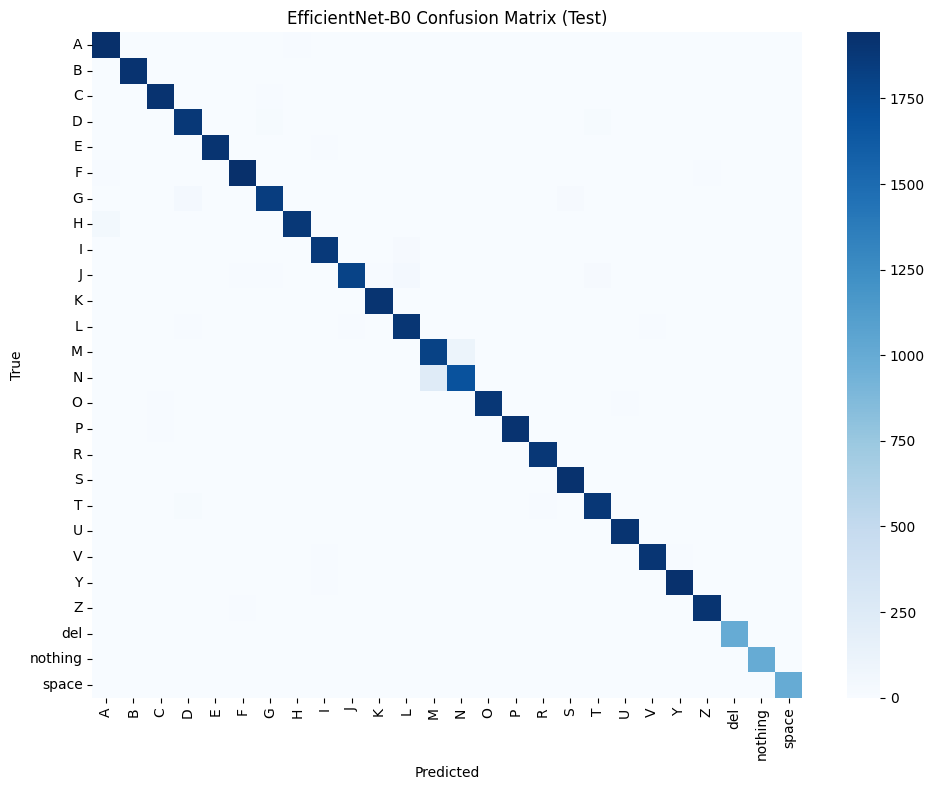

In [32]:

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names,
            cmap="Blues", fmt="d")
plt.title("EfficientNet-B0 Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [33]:

torch.save(model_eff_final.state_dict(), "efficientnet_b0_final.pth")
print("Model kaydedildi: efficientnet_b0_final.pth")


Model kaydedildi: efficientnet_b0_final.pth


In [34]:

train_loss = history_freeze["train_loss"] + history_finetune["train_loss"]
val_loss   = history_freeze["val_loss"]   + history_finetune["val_loss"]

train_acc  = history_freeze["train_acc"]  + history_finetune["train_acc"]
val_acc    = history_freeze["val_acc"]    + history_finetune["val_acc"]

epochs = range(1, len(train_loss) + 1)

print("Toplam epoch:", len(train_loss))


Toplam epoch: 12


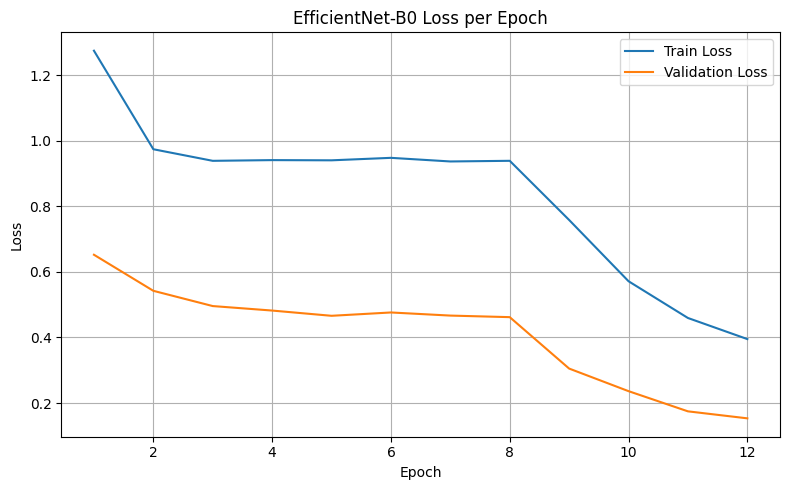

Kaydedildi: efficientnet_b0_loss.png


In [35]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Loss per Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("efficientnet_b0_loss.png", dpi=300)
plt.show()

print("Kaydedildi: efficientnet_b0_loss.png")


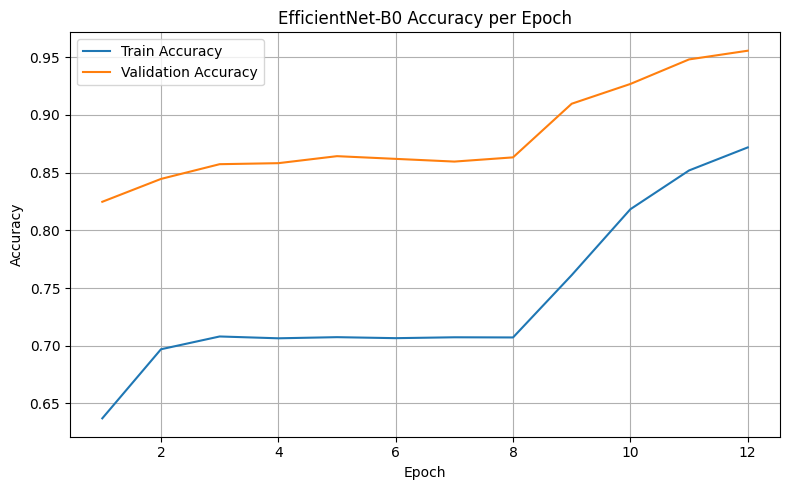

Kaydedildi: efficientnet_b0_accuracy.png


In [36]:


plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNet-B0 Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("efficientnet_b0_accuracy.png", dpi=300)
plt.show()

print("Kaydedildi: efficientnet_b0_accuracy.png")


In [37]:

import torch.nn as nn
from torchvision.models import inception_v3, Inception_V3_Weights


In [56]:

import torch.nn.functional as F

class InceptionV3Wrapper(nn.Module):
    def __init__(self, num_classes=26, dropout=0.5, freeze=True):
        super().__init__()

        self.model = inception_v3(
            weights=Inception_V3_Weights.IMAGENET1K_V1,
            aux_logits=True
        )


        if freeze:
            for param in self.model.parameters():
                param.requires_grad = False


        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )


        if self.model.AuxLogits is not None:
            aux_in = self.model.AuxLogits.fc.in_features
            self.model.AuxLogits.fc = nn.Linear(aux_in, num_classes)

    def forward(self, x):

        x = F.interpolate(x, size=(299, 299), mode="bilinear", align_corners=False)

        outputs = self.model(x)


        if isinstance(outputs, tuple):
            outputs = outputs[0]

        return outputs


def build_inception_v3(num_classes=26, dropout=0.5, freeze=True):
    return InceptionV3Wrapper(
        num_classes=num_classes,
        dropout=dropout,
        freeze=freeze
    ).to(device)


In [57]:

model_inc = build_inception_v3()

x, _ = next(iter(train_loader))
x = x.to(device)

model_inc.eval()
with torch.no_grad():
    outputs = model_inc(x)


    if isinstance(outputs, tuple):
        outputs = outputs[0]

print("Model output shape:", outputs.shape)


Model output shape: torch.Size([64, 26])


In [58]:

inception_configs = [
    {"lr": 1e-3,  "batch": 64,  "opt": "adam"},
    {"lr": 5e-4,  "batch": 64,  "opt": "adam"},
    {"lr": 3e-4,  "batch": 128, "opt": "adam"},
    {"lr": 5e-4,  "batch": 64,  "opt": "sgd"},
]

print("InceptionV3 tuning config sayısı:", len(inception_configs))


InceptionV3 tuning config sayısı: 4


In [59]:

TUNING_EPOCHS = 2
print("Tuning epochs:", TUNING_EPOCHS)


Tuning epochs: 2


In [60]:

def get_optimizer(model, lr, opt_name):

    params = filter(lambda p: p.requires_grad, model.parameters())

    if opt_name == "adam":
        return torch.optim.Adam(params, lr=lr)

    elif opt_name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)

    else:
        raise ValueError("Bilinmeyen optimizer")


In [61]:

inception_tuning_results = []

for i, cfg in enumerate(inception_configs, start=1):
    print(f"\n==================== InceptionV3 Tuning {i}/{len(inception_configs)} ====================")
    print("Config:", cfg)


    train_loader, val_loader, _ = get_dataloaders(
        train_dataset,
        val_dataset,
        test_dataset,
        batch_size=cfg["batch"]
    )


    model = build_inception_v3(
        num_classes=26,
        dropout=0.5,
        freeze=True
    )


    optimizer = get_optimizer(
        model,
        lr=cfg["lr"],
        opt_name=cfg["opt"]
    )


    history = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=TUNING_EPOCHS
    )

    best_val_acc = max(history["val_acc"])
    inception_tuning_results.append({
        "config": cfg,
        "best_val_acc": best_val_acc
    })

    print(f"--> Best Val Acc: {best_val_acc:.4f}")



==================== InceptionV3 Tuning 1/4 ====================
Config: {'lr': 0.001, 'batch': 64, 'opt': 'adam'}
Epoch [1/2] | Train Loss: 1.9071 Acc: 0.4359 | Val Loss: 1.0711 Acc: 0.7299
Epoch [2/2] | Train Loss: 1.6577 Acc: 0.4933 | Val Loss: 0.9480 Acc: 0.7485
--> Best Val Acc: 0.7485

==================== InceptionV3 Tuning 2/4 ====================
Config: {'lr': 0.0005, 'batch': 64, 'opt': 'adam'}
Epoch [1/2] | Train Loss: 2.0601 Acc: 0.4137 | Val Loss: 1.2880 Acc: 0.7128
Epoch [2/2] | Train Loss: 1.6193 Acc: 0.5103 | Val Loss: 1.0557 Acc: 0.7511
--> Best Val Acc: 0.7511

==================== InceptionV3 Tuning 3/4 ====================
Config: {'lr': 0.0003, 'batch': 128, 'opt': 'adam'}
Epoch [1/2] | Train Loss: 2.3780 Acc: 0.3528 | Val Loss: 1.6962 Acc: 0.6557
Epoch [2/2] | Train Loss: 1.7626 Acc: 0.5010 | Val Loss: 1.3281 Acc: 0.7165
--> Best Val Acc: 0.7165

==================== InceptionV3 Tuning 4/4 ====================
Config: {'lr': 0.0005, 'batch': 64, 'opt': 'sgd'}
Ep

In [68]:

BEST_INCEPTION_CFG = {
    "lr": 0.0005,
    "batch": 64,
    "opt": "adam"
}

print("BEST_INCEPTION_CFG ayarlandı:", BEST_INCEPTION_CFG)


BEST_INCEPTION_CFG ayarlandı: {'lr': 0.0005, 'batch': 64, 'opt': 'adam'}


In [70]:

FINAL_BATCH = BEST_INCEPTION_CFG["batch"]
FINAL_LR    = BEST_INCEPTION_CFG["lr"]
FINAL_OPT   = BEST_INCEPTION_CFG["opt"]

print("Final Config:",
      "Batch =", FINAL_BATCH,
      "| LR =", FINAL_LR,
      "| Opt =", FINAL_OPT)

train_loader, val_loader, test_loader = get_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset,
    batch_size=FINAL_BATCH
)


model_inc_final = build_inception_v3(
    num_classes=26,
    dropout=0.5,
    freeze=True
)


optimizer = get_optimizer(
    model_inc_final,
    lr=FINAL_LR,
    opt_name=FINAL_OPT
)

print("InceptionV3 final training hazır (freeze=True)")


Final Config: Batch = 64 | LR = 0.0005 | Opt = adam
InceptionV3 final training hazır (freeze=True)


In [73]:
EPOCHS = 15

history_inc_final = train_model(
    model_inc_final,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=EPOCHS
)


Epoch [1/15] | Train Loss: 2.0502 Acc: 0.4162 | Val Loss: 1.2763 Acc: 0.7139
Epoch [2/15] | Train Loss: 1.6226 Acc: 0.5091 | Val Loss: 1.0590 Acc: 0.7539
Epoch [3/15] | Train Loss: 1.5694 Acc: 0.5177 | Val Loss: 0.9572 Acc: 0.7732
Epoch [4/15] | Train Loss: 1.5639 Acc: 0.5191 | Val Loss: 0.9236 Acc: 0.7739
Epoch [5/15] | Train Loss: 1.5575 Acc: 0.5219 | Val Loss: 0.9072 Acc: 0.7760
Epoch [6/15] | Train Loss: 1.5597 Acc: 0.5208 | Val Loss: 0.9053 Acc: 0.7722
Epoch [7/15] | Train Loss: 1.5556 Acc: 0.5238 | Val Loss: 0.8805 Acc: 0.7796
Epoch [8/15] | Train Loss: 1.5516 Acc: 0.5232 | Val Loss: 0.8816 Acc: 0.7755
Epoch [9/15] | Train Loss: 1.5521 Acc: 0.5233 | Val Loss: 0.8825 Acc: 0.7768
Epoch [10/15] | Train Loss: 1.5448 Acc: 0.5245 | Val Loss: 0.8618 Acc: 0.7838
Epoch [11/15] | Train Loss: 1.5536 Acc: 0.5240 | Val Loss: 0.8690 Acc: 0.7770
Epoch [12/15] | Train Loss: 1.5537 Acc: 0.5245 | Val Loss: 0.8656 Acc: 0.7800
Epoch [13/15] | Train Loss: 1.5556 Acc: 0.5245 | Val Loss: 0.8667 Acc: 0.

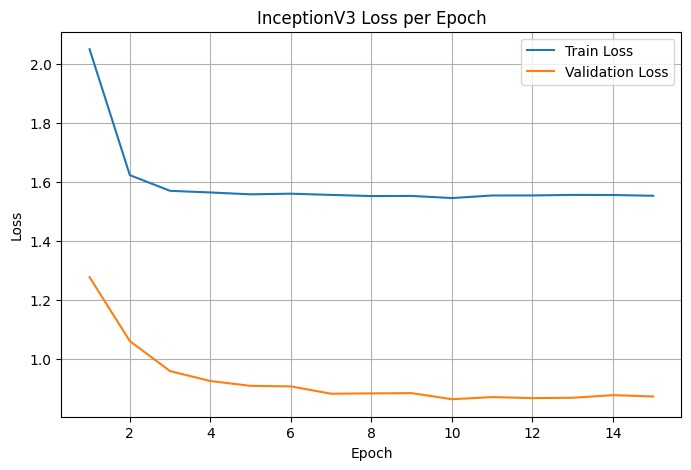

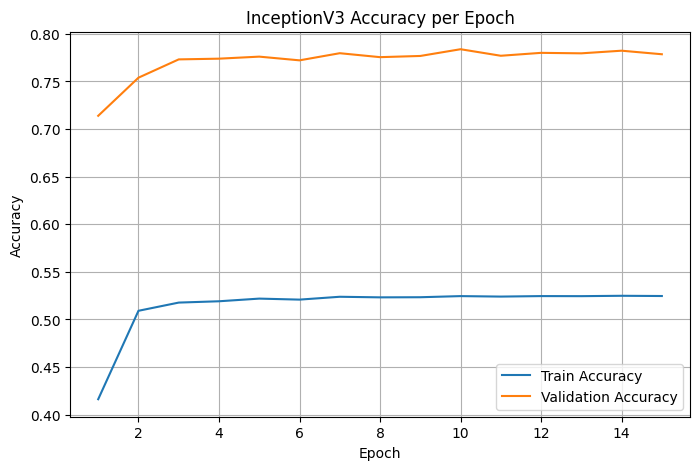

Grafikler kaydedildi:
- inceptionv3_loss.png
- inceptionv3_accuracy.png


In [74]:
import matplotlib.pyplot as plt

train_loss = history_inc_final["train_loss"]
val_loss   = history_inc_final["val_loss"]
train_acc  = history_inc_final["train_acc"]
val_acc    = history_inc_final["val_acc"]

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("InceptionV3 Loss per Epoch")
plt.legend()
plt.grid(True)
plt.savefig("inceptionv3_loss.png")
plt.show()


plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("InceptionV3 Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.savefig("inceptionv3_accuracy.png")
plt.show()

print("Grafikler kaydedildi:")
print("- inceptionv3_loss.png")
print("- inceptionv3_accuracy.png")


In [75]:
torch.save(model_inc_final.state_dict(), "inceptionv3_final.pth")
print("Model kaydedildi: inceptionv3_final.pth")


Model kaydedildi: inceptionv3_final.pth


In [76]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import numpy as np

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)


            if isinstance(outputs, tuple):
                outputs = outputs[0]

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


In [77]:
y_true_inc, y_pred_inc = evaluate_model(
    model_inc_final,
    test_loader,
    device
)

test_acc = accuracy_score(y_true_inc, y_pred_inc)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_inc, y_pred_inc, average="macro"
)

print("===== InceptionV3 TEST SONUÇLARI =====")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true_inc, y_pred_inc, target_names=class_names))


===== InceptionV3 TEST SONUÇLARI =====
Accuracy  : 0.7612
Precision : 0.7939
Recall    : 0.7746
F1-score  : 0.7749

Classification Report:

              precision    recall  f1-score   support

           A       0.59      0.85      0.70      1962
           B       0.94      0.91      0.92      1929
           C       0.61      0.86      0.71      1953
           D       0.74      0.56      0.63      1948
           E       0.88      0.69      0.77      1943
           F       0.91      0.73      0.81      1973
           G       0.71      0.72      0.71      1947
           H       0.83      0.59      0.69      1952
           I       0.69      0.83      0.75      1933
           J       0.60      0.70      0.65      1944
           K       0.93      0.71      0.81      1950
           L       0.77      0.63      0.69      1958
           M       0.87      0.55      0.67      1934
           N       0.62      0.82      0.70      1941
           O       0.79      0.70      0.74      

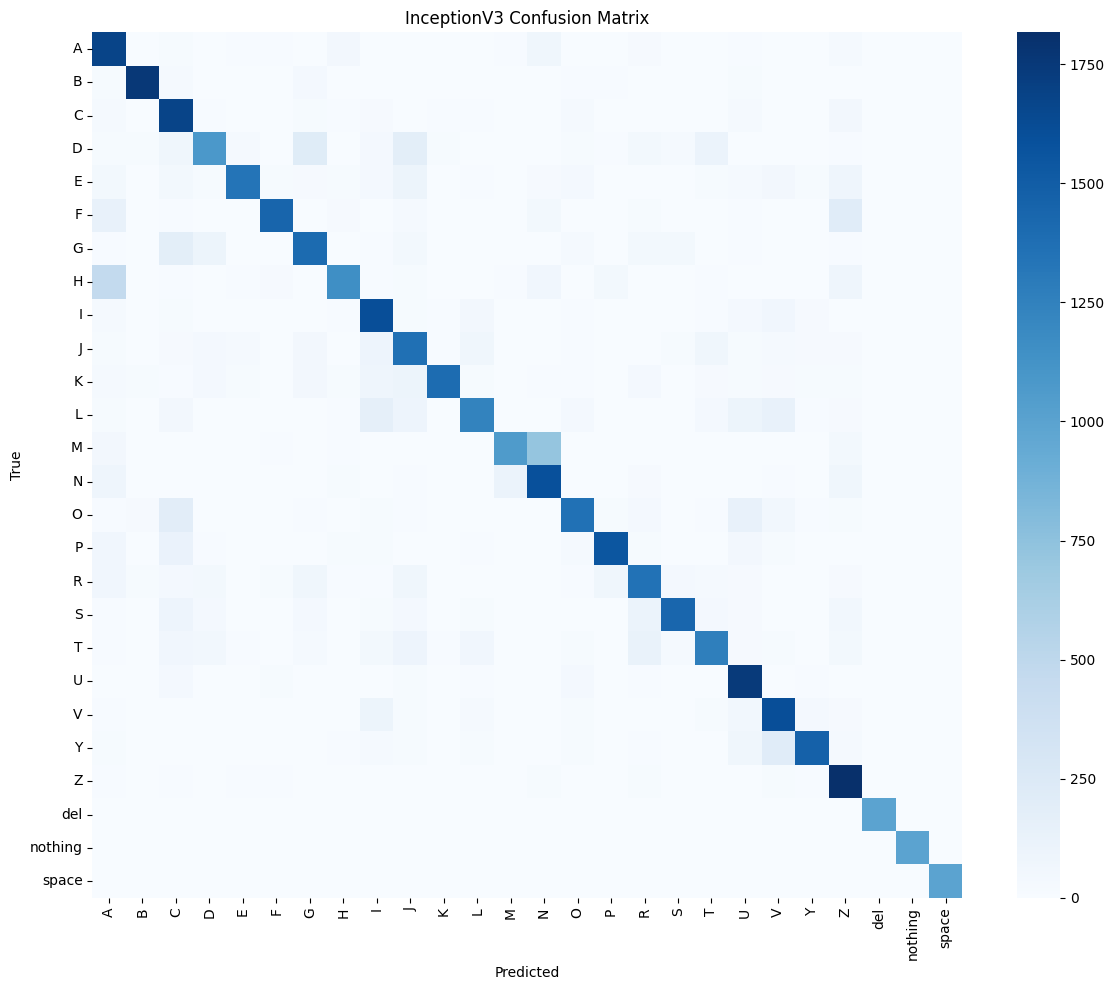

Confusion Matrix kaydedildi: inceptionv3_confusion_matrix.png


In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_inc, y_pred_inc)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("InceptionV3 Confusion Matrix")
plt.tight_layout()
plt.savefig("inceptionv3_confusion_matrix.png")
plt.show()

print("Confusion Matrix kaydedildi: inceptionv3_confusion_matrix.png")


In [81]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# EfficientNet test evaluation
y_true_eff, y_pred_eff = evaluate_model(
    model_eff_final,
    test_loader,
    device
)

test_acc_eff = accuracy_score(y_true_eff, y_pred_eff)

precision_eff, recall_eff, f1_eff, _ = precision_recall_fscore_support(
    y_true_eff,
    y_pred_eff,
    average="macro"
)

print("EfficientNet Test Metrikleri:")
print(f"Accuracy  : {test_acc_eff:.4f}")
print(f"Precision : {precision_eff:.4f}")
print(f"Recall    : {recall_eff:.4f}")
print(f"F1-score  : {f1_eff:.4f}")


EfficientNet Test Metrikleri:
Accuracy  : 0.9696
Precision : 0.9715
Recall    : 0.9713
F1-score  : 0.9713


In [84]:
import pandas as pd

# Ortak sonuç tablosu (Ali)
results_table = pd.DataFrame([
    {
        "Model": "Ali – EfficientNet-B0",
        "Accuracy": test_acc_eff,
        "Precision (macro)": precision_eff,
        "Recall (macro)": recall_eff,
        "F1-score (macro)": f1_eff,
        "Not / En İyi Ayar": "LR=0.001, Batch=64, Adam"
    },
    {
        "Model": "Ali – InceptionV3",
        "Accuracy": test_acc,
        "Precision (macro)": precision,
        "Recall (macro)": recall,
        "F1-score (macro)": f1,
        "Not / En İyi Ayar": "LR=0.0005, Batch=64, Adam"
    }
])

# Tabloyu göster
display(results_table)

# CSV olarak kaydet
results_table.to_csv("final_model_comparison_ali.csv", index=False)
print("Tablo kaydedildi: final_model_comparison_ali.csv")


,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro),Not / En İyi Ayar
0,Ali – EfficientNet-B0,0.969621,0.971526,0.971304,0.971266,"LR=0.001, Batch=64, Adam"
1,Ali – InceptionV3,0.761193,0.793914,0.774588,0.774883,"LR=0.0005, Batch=64, Adam"


Tablo kaydedildi: final_model_comparison_ali.csv


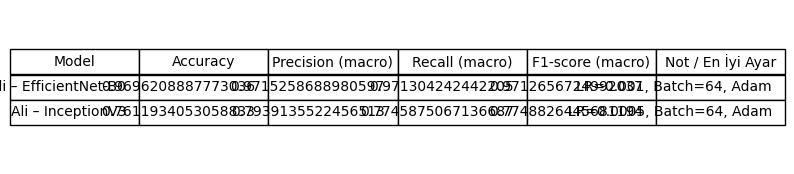

PNG tablo kaydedildi: final_model_comparison_ali.png


In [85]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=results_table.values,
    colLabels=results_table.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.savefig("final_model_comparison_ali.png", bbox_inches="tight")
plt.show()

print("PNG tablo kaydedildi: final_model_comparison_ali.png")
